In [1]:
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    precision_recall_curve
)
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

DATA_ROOT = REPO_ROOT / "data/03_ma_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

SCORES_PATH = OUTPUT_DIR / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "ae_metrics.csv"

val_df = pd.read_csv(OUTPUT_DIR / "val_scores_with_baselines.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test_scores_with_baselines.csv")


#### Threshold Selection on Validation Set only 

In [3]:
def select_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return float(np.max(scores))

    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx])

#### Evaluate Threshold on Test Set only 

In [4]:
def evaluate_at_threshold(y_true, scores, threshold):

    y_pred = (scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "pr_auc": float(average_precision_score(y_true, scores)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }


### Evaluation  

In [21]:
score_columns = [
    "global_mse",
    "global_mae",
    "ver_max",
    "ver_topk",
    "iso_forest",
    "pca_recon"
]

results = []

for score_name in score_columns:

    # --- Threshold auf Validation
    threshold = select_best_f1_threshold(
        val_df["label"].values,
        val_df[score_name].values
    )

    # --- Test Evaluation
    metrics = evaluate_at_threshold(
        test_df["label"].values,
        test_df[score_name].values,
        threshold
    )

    results.append({
        "method": score_name,
        "threshold": threshold,
        **metrics
    })


results_df = pd.DataFrame(results)

In [6]:
# create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("pr_auc", ascending=False)

results_df.round({
    "threshold": 6,
    "pr_auc": 3,
    "f1": 3,
    "precision": 3,
    "recall": 3
})

,method,threshold,pr_auc,f1,precision,recall,tn,fp,fn,tp
2,ver_max,0.004584,0.966,0.927,1.000,0.864,2478,0,3,19
5,pca_recon,0.000440,0.941,0.821,0.941,0.727,2477,1,6,16
3,ver_topk,0.003590,0.924,0.706,1.000,0.545,2478,0,10,12
4,iso_forest,0.025164,0.771,0.703,0.867,0.591,2476,2,9,13
0,global_mse,0.001102,0.593,0.625,1.000,0.455,2478,0,12,10
1,global_mae,0.013986,0.324,0.429,1.000,0.273,2478,0,16,6


In [8]:
results_df.to_csv(OUTPUT_DIR / "baseline_comparison_table.csv", index=False)

# Plot PR curves for all methods 

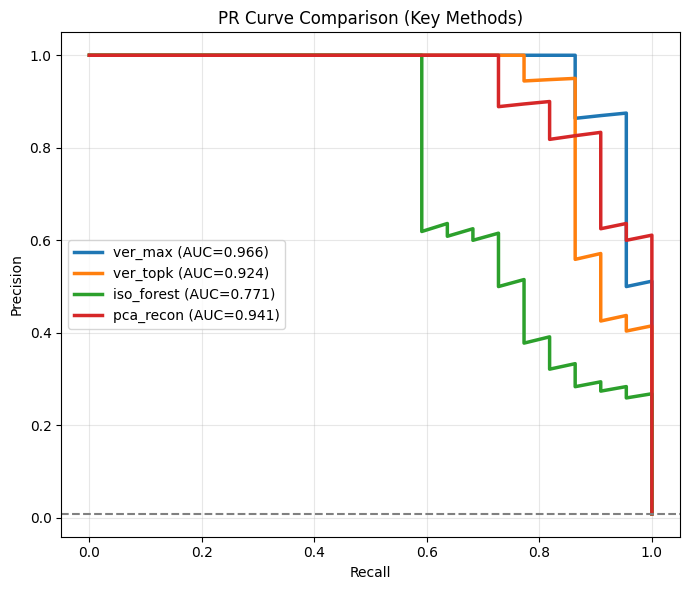

In [7]:
plot_methods = [
    "ver_max",
    "ver_topk",
    "iso_forest",
    "pca_recon"
]

plt.figure(figsize=(7,6))

for score in plot_methods:

    precision, recall, _ = precision_recall_curve(
        test_df["label"],
        test_df[score]
    )

    pr_auc = average_precision_score(
        test_df["label"],
        test_df[score]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2.5,
        label=f"{score} (AUC={pr_auc:.3f})"
    )

# Random baseline
baseline = test_df["label"].mean()
plt.axhline(y=baseline, linestyle="--", color="gray")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison (Key Methods)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## PLot PR Curves for all methods (Best highlighted) 

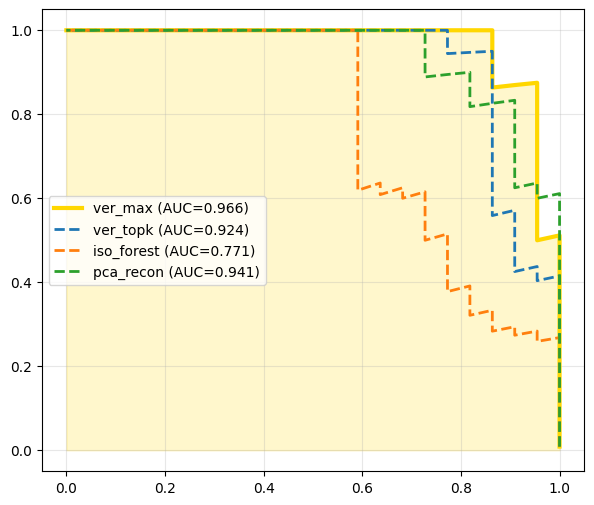

In [8]:
plt.figure(figsize=(7,6))

for score in plot_methods:

    precision, recall, _ = precision_recall_curve(
        test_df["label"],
        test_df[score]
    )

    pr_auc = average_precision_score(
        test_df["label"],
        test_df[score]
    )

    if score == "ver_max":
        plt.plot(recall, precision, linewidth=3, color="gold",
                 label=f"{score} (AUC={pr_auc:.3f})")

        plt.fill_between(recall, precision, alpha=0.2, color="gold")

    else:
        plt.plot(recall, precision, linewidth=2,
                 linestyle="--",
                 label=f"{score} (AUC={pr_auc:.3f})")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Paper-Ready Visualization 

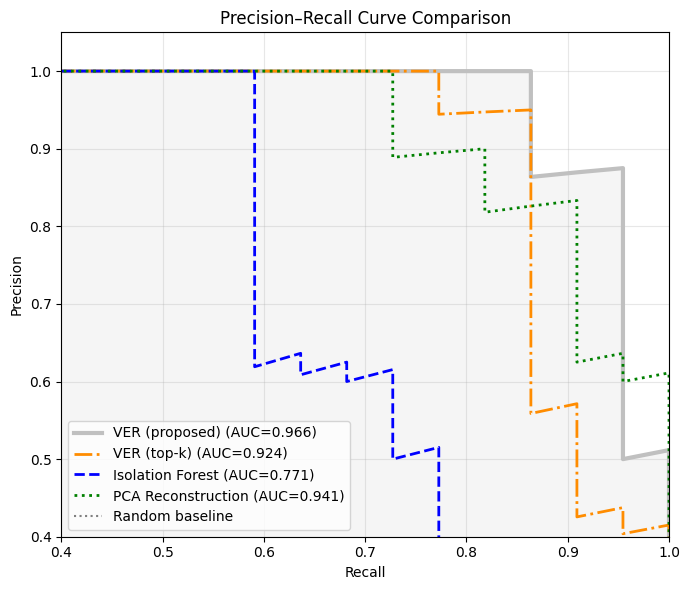

In [9]:

plt.figure(figsize=(7,6))

# --- VER (Hauptmethode)
precision, recall, _ = precision_recall_curve(
    test_df["label"], test_df["ver_max"]
)
pr_auc = average_precision_score(test_df["label"], test_df["ver_max"])

plt.plot(
    recall,
    precision,
    color="silver",
    linewidth=3,
    label=f"VER (proposed) (AUC={pr_auc:.3f})"
)

plt.fill_between(
    recall,
    precision,
    color="silver",
    alpha=0.15
)

# --- Zweite VER-Variante (optional)
precision, recall, _ = precision_recall_curve(
    test_df["label"], test_df["ver_topk"]
)
pr_auc = average_precision_score(test_df["label"], test_df["ver_topk"])

plt.plot(
    recall,
    precision,
    color="darkorange",
    linewidth=2,
    linestyle="-.",
    label=f"VER (top-k) (AUC={pr_auc:.3f})"
)

# --- Isolation Forest
precision, recall, _ = precision_recall_curve(
    test_df["label"], test_df["iso_forest"]
)
pr_auc = average_precision_score(test_df["label"], test_df["iso_forest"])

plt.plot(
    recall,
    precision,
    linestyle="--",
    linewidth=2,
    color="blue",
    label=f"Isolation Forest (AUC={pr_auc:.3f})"
)

# --- PCA Baseline
precision, recall, _ = precision_recall_curve(
    test_df["label"], test_df["pca_recon"]
)
pr_auc = average_precision_score(test_df["label"], test_df["pca_recon"])

plt.plot(
    recall,
    precision,
    linestyle=":",
    linewidth=2,
    color="green",
    label=f"PCA Reconstruction (AUC={pr_auc:.3f})"
)

# --- Random baseline
baseline = test_df["label"].mean()
plt.axhline(
    y=baseline,
    linestyle=":",
    color="gray",
    linewidth=1.5,
    label="Random baseline"
)

# --- optional zoom (empfohlen!)
plt.xlim(0.4, 1.0)
plt.ylim(0.4, 1.05)

# --- Labels & Style
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


Figure X. Precision–Recall curve comparison of the proposed VER-based anomaly score and baseline methods.


The Vertical Error Rate (VER) significantly outperforms both global reconstruction metrics and classical anomaly detection approaches, including Isolation Forest and PCA-based reconstruction error.
The shaded area highlights the precision–recall trade-off of the proposed method.
Results demonstrate that localized residual evaluation improves detection of transient vibration anomalies under strong class imbalance. 

| Method             | PR-AUC    | F1        | Precision | Recall |
| ------------------ | --------- | --------- | --------- | ------ |
| global MSE         | 0.593     | 0.625     | 1.00      | 0.45   |
| PCA                | 0.941       | 0.821       | 0.941       | 0.727    |
| Iso Forest         | 0.771       | 0.703       | 0.867       | 0.591    |
| **VER (proposed)** | **0.966** | **0.927** | 1.00      | 0.86   |

“The proposed VER-based scoring achieves the highest PR-AUC and F1-score across all evaluated methods, confirming the benefit of localized residual analysis.”

# Histogram of reconstruction errors 


Using threshold: 0.004584
Using threshold: 0.004584


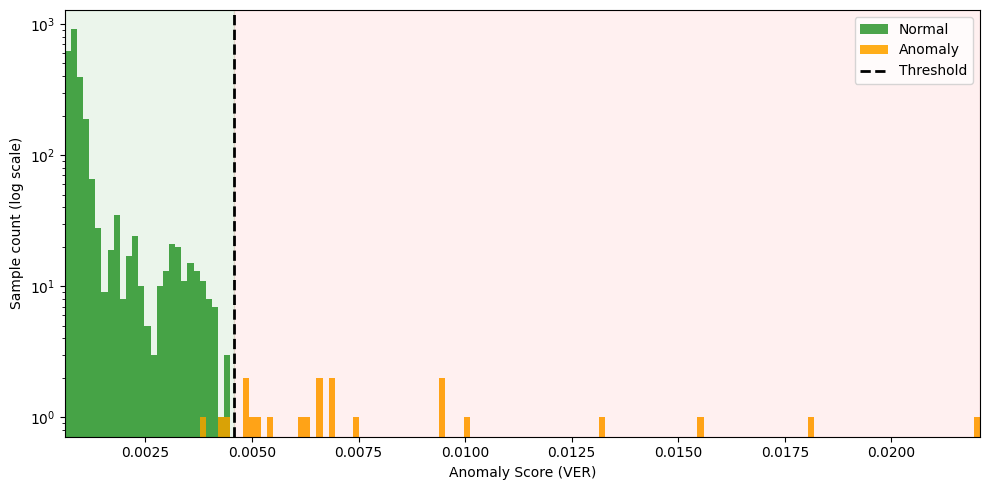

In [34]:

# ---------------------------------
# CONFIG
# ---------------------------------
SCORE_COL = "ver_max"
LABEL_COL = "label"  # optional

# ---------------------------------
# Threshold (aus validation!)
# ---------------------------------
threshold = results_df.loc[
    results_df["method"] == SCORE_COL, "threshold"
].iloc[0]

print(f"Using threshold: {threshold:.6f}")

# Falls du einen gespeicherten Threshold hast, besser:
# import json
# with open(THRESHOLD_PATH) as f:
#     threshold = json.load(f)["ver_max"]

print(f"Using threshold: {threshold:.6f}")

# ---------------------------------
# Daten
# ---------------------------------
scores = test_df[SCORE_COL].values

has_labels = LABEL_COL in test_df.columns
if has_labels:
    labels = test_df[LABEL_COL].values
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(10, 5))

# Bins fest definieren (wichtig für reproduzierbarkeit)
bins = np.linspace(scores.min(), scores.max(), 150)

# Gesamt-Histogramm (leicht grau im Hintergrund)
#plt.hist(scores, bins=bins, color="gray", alpha=0.3, label="All samples", log=True)

# Klassen getrennt (empfohlen)
if has_labels:
    plt.hist(normal_scores, bins=bins, color="green", alpha=0.7, label="Normal", log=True)
    #plt.hist(normal_scores, bins=bins, histtype="step", color="green", linewidth=1.5)
    plt.hist(anomaly_scores, bins=bins, color="orange", alpha=0.9, label="Anomaly", log=True)

# Threshold Linie
plt.axvline(threshold, color="black", linestyle="--", linewidth=2, label="Threshold")

# Optional: farbliche Bereiche
plt.axvspan(scores.min(), threshold, color="green", alpha=0.08)
plt.axvspan(threshold, scores.max(), color="red", alpha=0.06)

# Labels
plt.xlabel("Anomaly Score (VER)")
plt.ylabel("Sample count (log scale)")

# Achsen fein einstellen
plt.xlim(scores.min(), scores.max())

plt.legend()
plt.tight_layout()

# Save
plt.savefig(OUTPUT_DIR / "histogram_ver.png", dpi=300)

plt.show()


Confusion Matrix:
TN: 2478
FP: 0
FN: 3
TP: 19


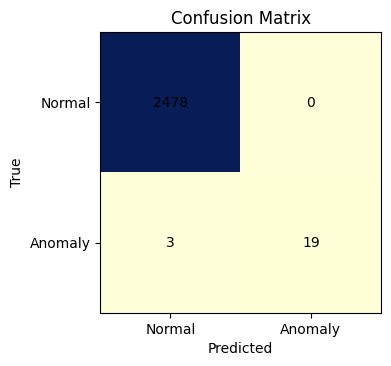

In [32]:

import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_true = test_df["label"].values
scores = test_df[SCORE_COL].values

y_pred = (scores >= threshold).astype(int)

# Confusion Matrix berechnen
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("Confusion Matrix:")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")


cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, cmap="YlGnBu")

# Labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Normal", "Anomaly"])
ax.set_yticklabels(["Normal", "Anomaly"])

# Zahlen anzeigen
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j],
                ha="center", va="center", color="black")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "confusion_matrix_ver.png", dpi=300)
plt.show()


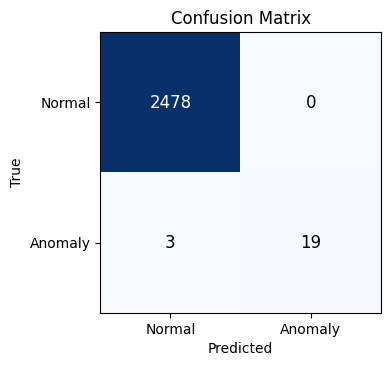

In [ ]:
fig, ax = plt.subplots(figsize=(4,4))

im = ax.imshow(cm, cmap="Blues")

# Labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Normal", "Anomaly"])
ax.set_yticklabels(["Normal", "Anomaly"])

# Zahlen + bessere Lesbarkeit
for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max()/2 else "black",
            fontsize=12
        )

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

plt.tight_layout()
#plt.savefig(OUTPUT_DIR / "confusion_matrix_ver.png", dpi=300)

plt.show()
